In [ ]:
!pip install bibtexparser pandas openpyxl matplotlib wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=e6133dbefbc4dc024dcf6624e8a307cfaf20960f5d3e8af442e06917677ae0f3
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


In [ ]:
import bibtexparser

with open("corpus_eixo2_lgbtqia_v2.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

print("Total de registros:", len(bib_database.entries))

Total de registros: 418


In [ ]:
campos = set()

for artigo in bib_database.entries:
    campos.update(artigo.keys())

for campo in sorted(campos):

    preenchidos = sum(
        1 for artigo in bib_database.entries
        if artigo.get(campo)
    )

    print(f"{campo}: {preenchidos}")

ENTRYTYPE: 418
ID: 418
author: 418
doi: 409
journal: 418
keywords: 0
number: 371
pages: 418
title: 418
volume: 362
year: 418


In [ ]:
import pandas as pd

dados = []

for artigo in bib_database.entries:
    dados.append({
        "Titulo": artigo.get("title", ""),
        "Autores": artigo.get("author", ""),
        "Ano": artigo.get("year", ""),
        "Periodico": artigo.get("journal", ""),
        "DOI": artigo.get("doi", "")
    })

df = pd.DataFrame(dados)

print(df.shape)

df.head()

(418, 5)


,Titulo,Autores,Ano,Periodico,DOI
0,Evidências de validade de uma escala sobre a L...,"Janaína Gularte Cardoso, Rudimar Antunes da Rocha",2024,Revista de Ciências da Administração,10.5007/2175-8077.2024.e80415
1,Cidadania consumerista: um olhar a partir da v...,Anderson Waldemar Moreira Paula,2024,Revista do Curso de Direito do UNIFOR,10.24862/rcdu.v15i2.1830
2,Bissexualidade em foco,"Helena Motta Monaco, Inácio Saldanha, Danieli ...",2024,Temáticas,10.20396/tematicas.v32i64.20059
3,Entre a cruz e a espada: dimensões do aparecim...,"Tomás Soares Pereira German, Regiane Lucas de ...",2024,Reciis,10.29397/reciis.v18i1.3808
4,La Niña Ancestral: Práticas Coloniais e Dispos...,"Arthur Daibert Machado Tavares, Fernando Pocah...",2024,Revista Polis e Psique,10.22456/2238-152x.126396


In [ ]:
df["Ano"].value_counts().sort_index()

,count
Ano,
2015,19
2016,20
2017,26
2018,40
2019,59
2020,60
2021,59
2022,57
2023,40


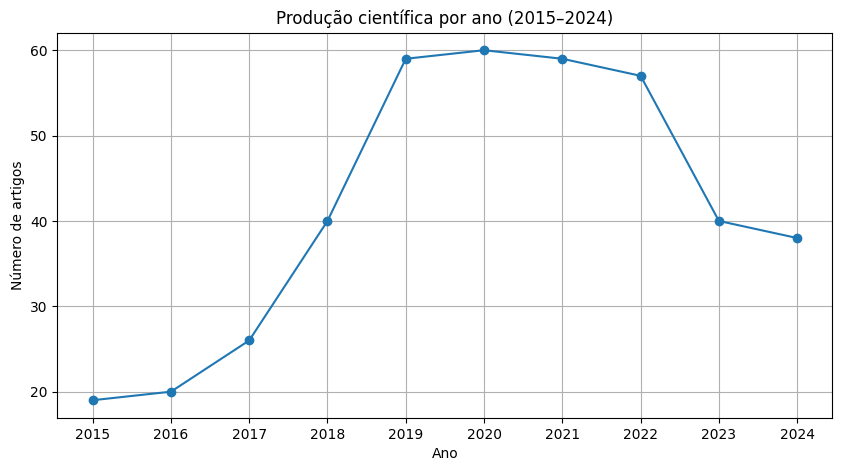

In [ ]:
import matplotlib.pyplot as plt

producao = df["Ano"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    producao.index,
    producao.values,
    marker="o"
)

plt.title("Produção científica por ano (2015–2024)")
plt.xlabel("Ano")
plt.ylabel("Número de artigos")

plt.grid(True)

plt.show()

In [ ]:
from collections import Counter

texto = " ".join(df["Titulo"].astype(str))

texto = texto.lower()

texto = texto.replace(",", " ")
texto = texto.replace(".", " ")
texto = texto.replace(":", " ")
texto = texto.replace(";", " ")
texto = texto.replace("-", " ")

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como","ao","aos",
    "à","às"
}

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

frequencia = Counter(palavras)

top20 = pd.DataFrame(
    frequencia.most_common(20),
    columns=["Palavra","Frequencia"]
)

top20

,Palavra,Frequencia
0,gênero,50
1,brasil,38
2,travestis,27
3,lgbt,26
4,queer,25
5,saúde,22
6,mulheres,21
7,diversidade,21
8,pessoas,20
9,sexual,20


In [ ]:
texto = " ".join(df["Titulo"].astype(str)).lower()

substituicoes = {
    "lgbtqia+": "lgbt",
    "lgbtqi+": "lgbt",
    "lgbtq": "lgbt",
    "lgbts": "lgbt",
    "travesti": "travestis",
    "transgênero": "trans"
}

for antigo, novo in substituicoes.items():
    texto = texto.replace(antigo, novo)

stopwords = {
    "de","da","do","das","dos",
    "a","o","as","os",
    "e","em","na","no","nas","nos",
    "para","por","com","um","uma",
    "sobre","entre","como",
    "análise","estudo","olhar"
}

from collections import Counter

palavras = [
    p for p in texto.split()
    if len(p) > 3 and p not in stopwords
]

freq = Counter(palavras)

top15 = pd.DataFrame(
    freq.most_common(15),
    columns=["Palavra","Frequencia"]
)

top15

,Palavra,Frequencia
0,lgbt,45
1,gênero,40
2,brasil,32
3,travestiss,23
4,queer,22
5,saúde,21
6,diversidade,21
7,trans,20
8,pessoas,20
9,mulheres,20


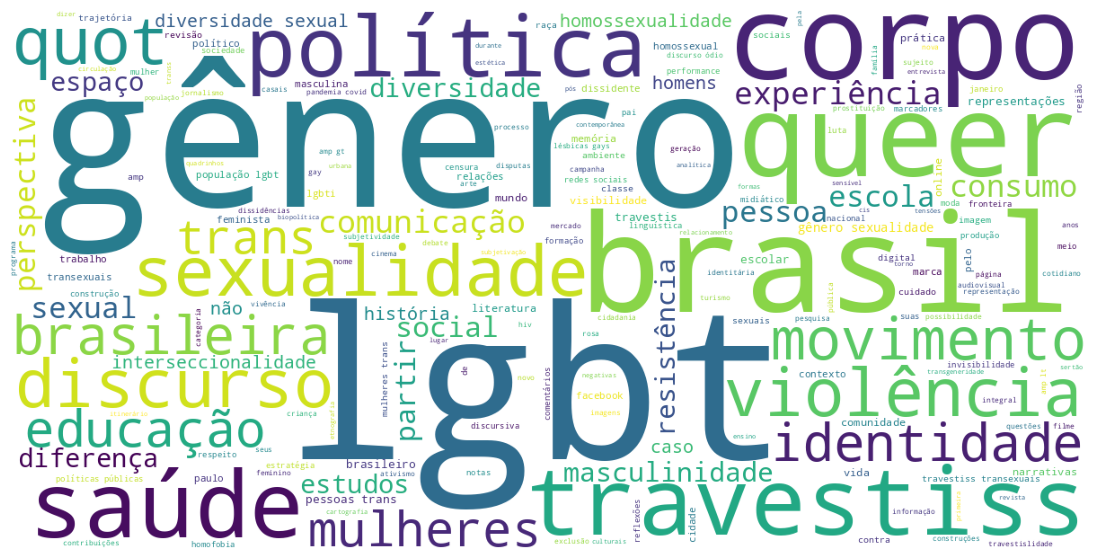

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate(" ".join(palavras))

plt.figure(figsize=(14,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [ ]:
from collections import Counter

lista_autores = []

for autores in df["Autores"]:

    autores_separados = autores.split(",")

    for autor in autores_separados:
        lista_autores.append(autor.strip())

freq_autores = Counter(lista_autores)

top_autores = pd.DataFrame(
    freq_autores.most_common(20),
    columns=["Autor","Publicacoes"]
)

top_autores

,Autor,Publicacoes
0,Fernando Seffner,4
1,Paulo Rennes Marçal Ribeiro,4
2,Fernando Pocahy,3
3,Inês Dourado,3
4,Maria Amélia de Sousa Mascena Veras,3
5,Victor Hugo Belarmino,3
6,Magda Dimenstein,3
7,Leandro Bessa,3
8,Guilherme Rodrigues Passamani,3
9,Sara Wagner York,3


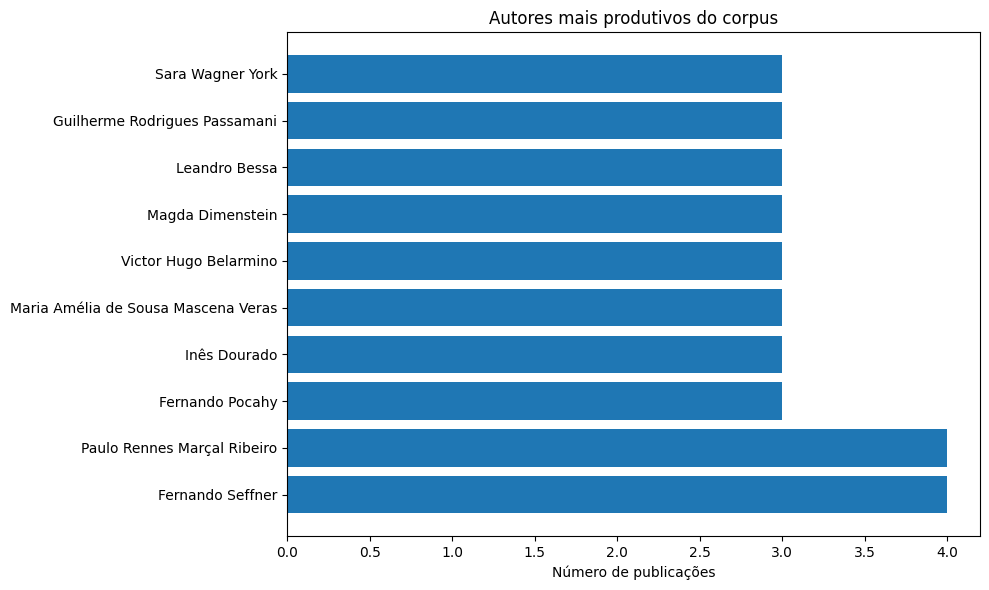

In [ ]:
import matplotlib.pyplot as plt

top10 = top_autores.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

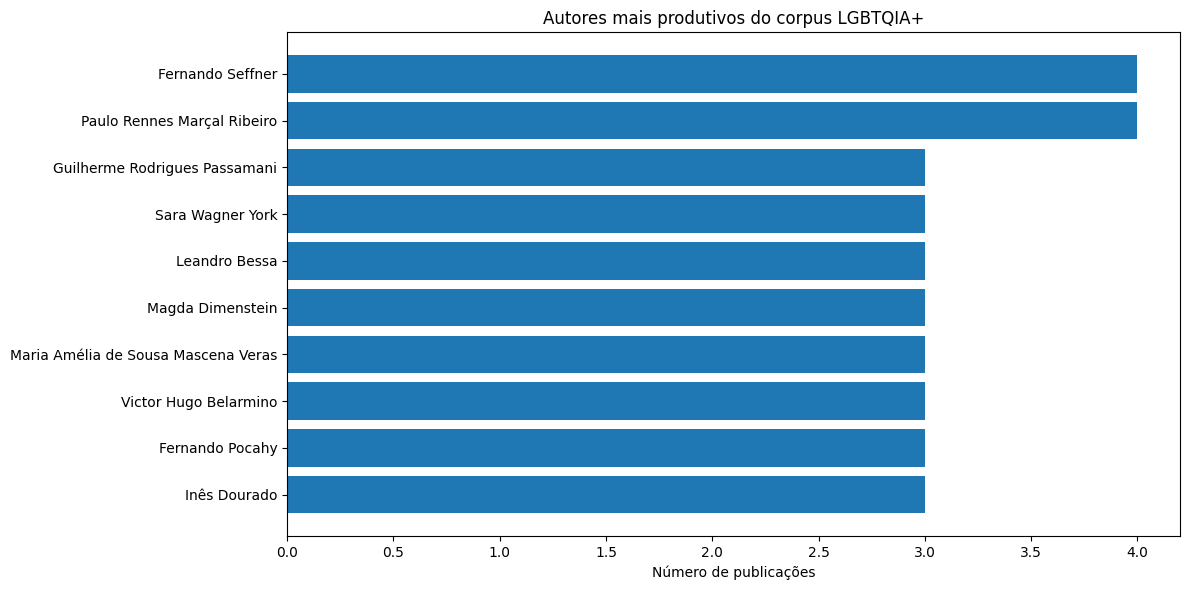

In [ ]:
top10 = top_autores.head(10).sort_values(
    by="Publicacoes",
    ascending=True
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Autor"],
    top10["Publicacoes"]
)

plt.title("Autores mais produtivos do corpus LGBTQIA+")
plt.xlabel("Número de publicações")

plt.tight_layout()
plt.show()

In [ ]:
top_periodicos = (
    df["Periodico"]
    .value_counts()
    .reset_index()
)

top_periodicos.columns = [
    "Periodico",
    "Publicacoes"
]

top_periodicos.head(15)

,Periodico,Publicacoes
0,Reciis,26
1,Revista Periódicus,20
2,Cadernos Pagu,13
3,Revista Estudos Feministas,12
4,Cadernos de Gênero e Diversidade,10
5,Sexualidad Salud y Sociedad (Rio de Janeiro),8
6,SHILAP Revista de lepidopterología,7
7,Diversidade e Educação,7
8,Research Society and Development,6
9,Intercom Revista Brasileira de Ciências da Com...,6


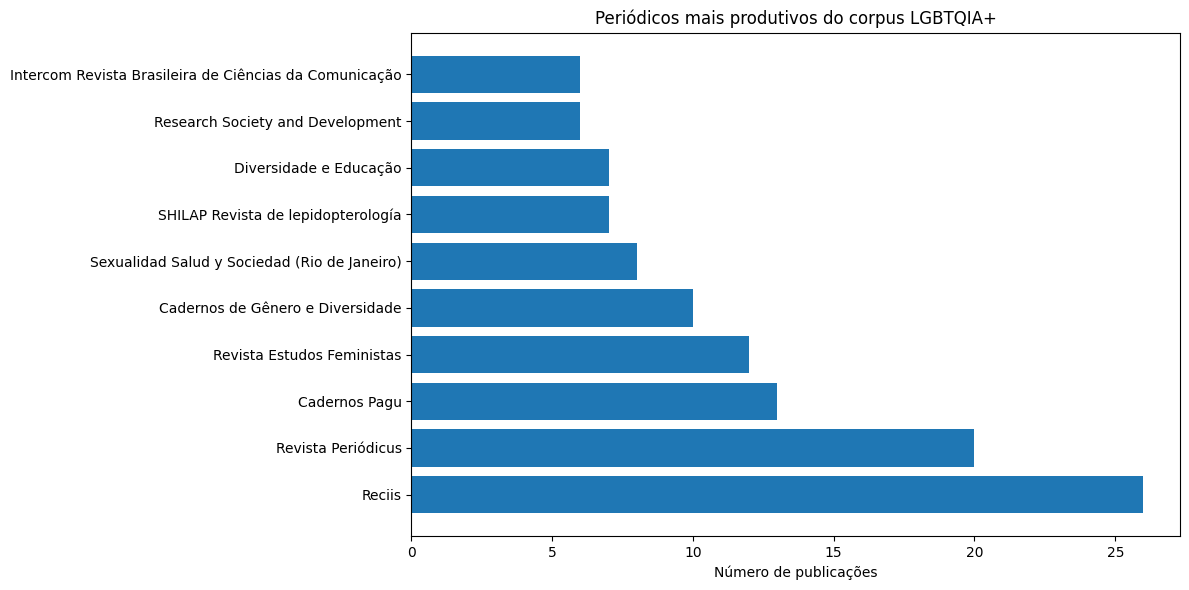

In [ ]:
top10_periodicos = top_periodicos.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_periodicos["Periodico"],
    top10_periodicos["Publicacoes"]
)

plt.title("Periódicos mais produtivos do corpus LGBTQIA+")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

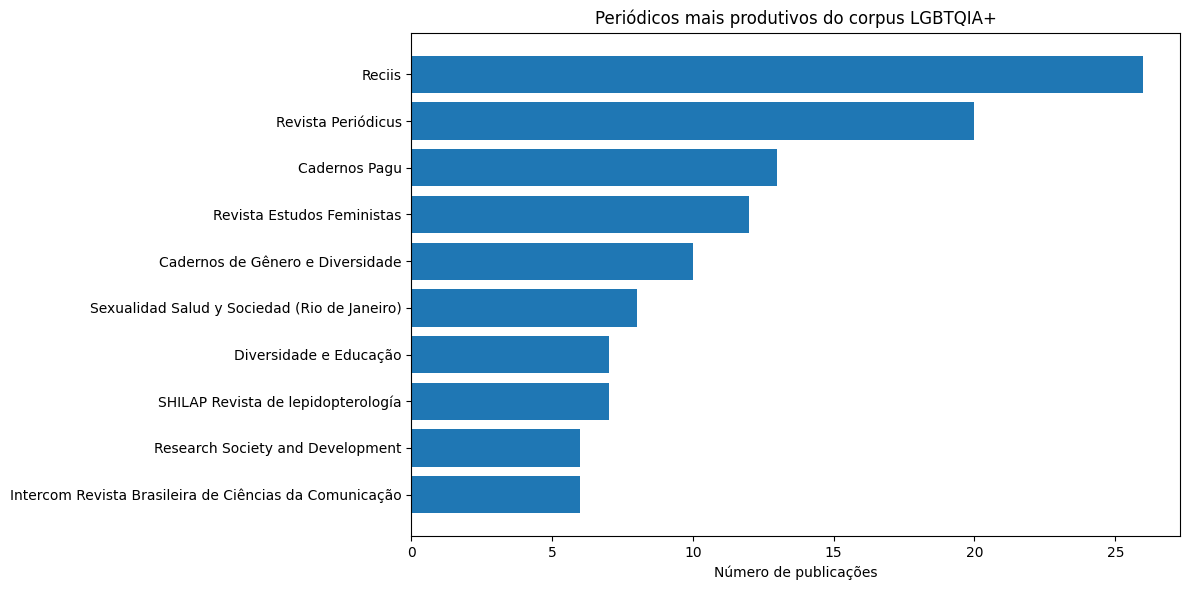

In [ ]:
top10_periodicos = (
    top_periodicos.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=True
    )
)

plt.figure(figsize=(12,6))

plt.barh(
    top10_periodicos["Periodico"],
    top10_periodicos["Publicacoes"]
)

plt.title("Periódicos mais produtivos do corpus LGBTQIA+")
plt.xlabel("Número de publicações")
plt.ylabel("")

plt.tight_layout()

plt.show()

In [ ]:
len(lista_autores)


892

In [ ]:
len(set(lista_autores))

803

In [ ]:
len(lista_autores) / len(df)

2.1339712918660285

In [ ]:
top_autores.to_excel(
    "autores_lgbtqia.xlsx",
    index=False
)

In [ ]:
top_periodicos.to_excel(
    "periodicos_lgbtqia.xlsx",
    index=False
)

In [ ]:
producao_ano = (
    df["Ano"]
    .value_counts()
    .sort_index()
    .reset_index()
)

producao_ano.columns = [
    "Ano",
    "Publicacoes"
]

producao_ano.to_excel(
    "producao_por_ano_lgbtqia.xlsx",
    index=False
)

In [ ]:
df = pd.DataFrame(dados)

In [ ]:
df.to_excel(
    "corpus_lgbtqia_completo.xlsx",
    index=False
)

print("Planilha salva!")

Planilha salva!


In [ ]:
import os

os.listdir()

['.config',
 'producao_por_ano_lgbtqia.xlsx',
 'corpus_eixo2_lgbtqia_v2.bib',
 'autores_lgbtqia.xlsx',
 'corpus_lgbtqia_completo.xlsx',
 'periodicos_lgbtqia.xlsx',
 'sample_data']

In [ ]:
df.to_excel("corpus_lgbtqia_completo.xlsx", index=False)
top_autores.to_excel("autores_lgbtqia.xlsx", index=False)
top_periodicos.to_excel("periodicos_lgbtqia.xlsx", index=False)
producao_ano.to_excel("producao_por_ano_lgbtqia.xlsx", index=False)

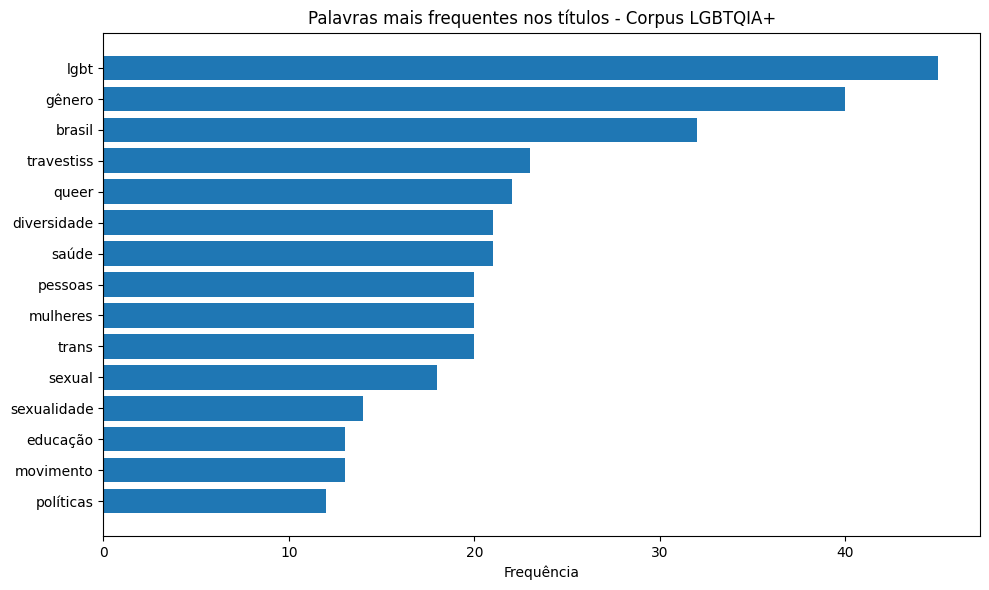

In [ ]:
import matplotlib.pyplot as plt

top15 = (
    top15
    .sort_values(
        by="Frequencia",
        ascending=True
    )
)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Palavra"],
    top15["Frequencia"]
)

plt.title("Palavras mais frequentes nos títulos - Corpus LGBTQIA+")
plt.xlabel("Frequência")
plt.ylabel("")

plt.tight_layout()

plt.show()

In [ ]:
periodicos_excluir = [
    "SHILAP Revista de lepidopterología"
]

df_limpo = df[
    ~df["Periodico"].isin(periodicos_excluir)
]

In [ ]:
from collections import Counter
import pandas as pd

freq_periodicos = Counter(df_limpo["Periodico"])

top_periodicos = pd.DataFrame(
    freq_periodicos.most_common(20),
    columns=["Periodico", "Publicacoes"]
)

top_periodicos.head(15)

,Periodico,Publicacoes
0,Reciis,26
1,Revista Periódicus,20
2,Cadernos Pagu,13
3,Revista Estudos Feministas,12
4,Cadernos de Gênero e Diversidade,10
5,Sexualidad Salud y Sociedad (Rio de Janeiro),8
6,Diversidade e Educação,7
7,Research Society and Development,6
8,Intercom Revista Brasileira de Ciências da Com...,6
9,Contemporânea - revista de sociologia da UFSCar,5


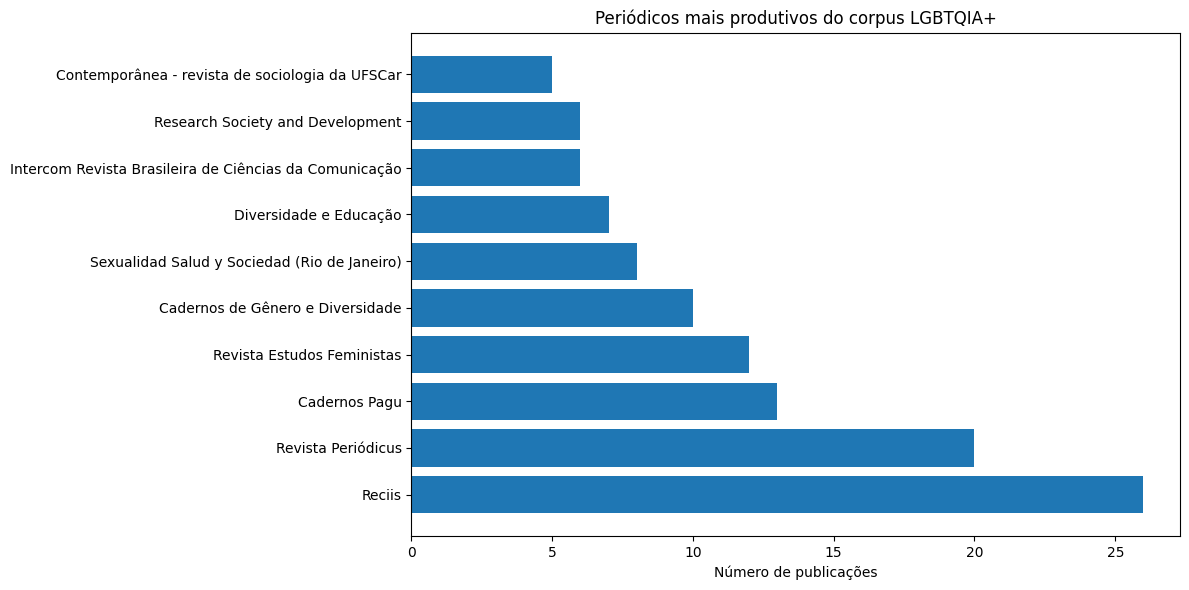

In [ ]:
import matplotlib.pyplot as plt

top10 = (
    top_periodicos.head(10)
    .sort_values(
        by="Publicacoes",
        ascending=True
    )
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Periodico"],
    top10["Publicacoes"]
)

plt.gca().invert_yaxis()

plt.title("Periódicos mais produtivos do corpus LGBTQIA+")
plt.xlabel("Número de publicações")

plt.tight_layout()

plt.show()

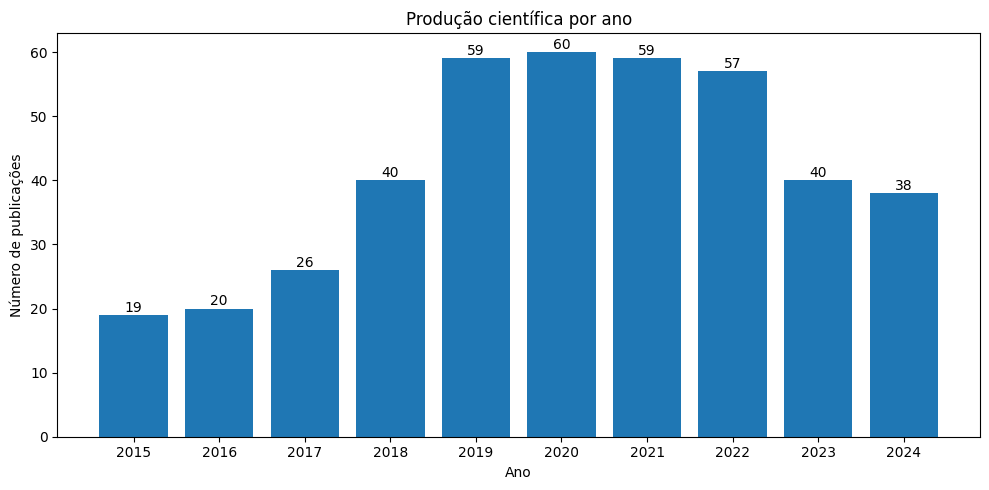

In [ ]:
import matplotlib.pyplot as plt

producao_ano = (
    df["Ano"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

barras = plt.bar(
    producao_ano.index.astype(str),
    producao_ano.values
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.5,
        str(int(altura)),
        ha='center'
    )

plt.title("Produção científica por ano")
plt.xlabel("Ano")
plt.ylabel("Número de publicações")

plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

In [ ]:
texto = " ".join(df["Titulo"].astype(str)).lower()

NameError: name 'df' is not defined

In [ ]:
texto_corrigido = texto.replace(
    "travestiss",
    "travestis"
)

NameError: name 'texto' is not defined

In [ ]:
df_lgbt.head()

NameError: name 'df_lgbt' is not defined

In [ ]:
df.shape

NameError: name 'df' is not defined

In [ ]:
import bibtexparser
import pandas as pd

with open("corpus_eixo2_lgbtqia_v2.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

dados = []

for artigo in bib_database.entries:
    dados.append({
        "Titulo": artigo.get("title", ""),
        "Autores": artigo.get("author", ""),
        "Ano": artigo.get("year", ""),
        "Periodico": artigo.get("journal", "")
    })

df = pd.DataFrame(dados)

print(df.shape)

ModuleNotFoundError: No module named 'bibtexparser'

In [ ]:
import os

os.listdir()

['.config', 'sample_data']

In [ ]:
!pip install bibtexparser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=0878be45cc061e011d39c109528d7d0618677fab43d58fe848f01ea0c1de83b2
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Classroom',
 'Documento sem título (8).gdoc',
 'FORMULARIO-dados pessoaisPAE 2.pdf',
 'Tabela de Resumos (1).xlsx',
 'Tabela de Resumos.xlsx',
 'Documento sem título (7).gdoc',
 'Agnes - Propesq PP 2026.pdf',
 'Propostas de Eventos para ArC2 ECA-USP: Extensão e Inclusão e Pertencimento.gdoc',
 'Documento sem título (6).gdoc',
 ' ESTUDO BIBLIOMÉTRICO .gdoc',
 'Documento sem título (5).gdoc',
 'Documento sem título (4).gdoc',
 'PLANO DE DISCIPLINA - Publicidade Antirracista no Brasil: Representações Raciais, Rupturas e Ambivalências.gdoc',
 'Formulário sem título.gform',
 'hipóteses de trabalho.gdoc',
 'Documento sem título (3).gdoc',
 'Documento sem título (2).gdoc',
 'TESTE INTERCOM .gdoc',
 'Rascunhos de NOBLE.gdoc',
 '"consumo" OR "consumidor*" OR "consumption" OR "consumer behavior".gdoc',
 'Documento sem título (1).gdoc',
 'analise lgbtqia+.gdoc',
 'Documento sem título.gdoc',
 'ANALISE NEGROS.gdoc',
 'rascunho do artigo.gdoc']

In [ ]:
import os

for raiz, pastas, arquivos in os.walk('/content/drive/MyDrive'):
    for arquivo in arquivos:
        if arquivo.endswith('.bib'):
            print(os.path.join(raiz, arquivo))

In [ ]:
import os

for raiz, pastas, arquivos in os.walk('/content/drive/MyDrive'):
    for arquivo in arquivos:
        if arquivo.endswith('.bib'):
            print(os.path.join(raiz, arquivo))

In [ ]:
import bibtexparser

with open("corpus_eixo2_lgbtqia_v2.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

print(len(bib_database.entries))

FileNotFoundError: [Errno 2] No such file or directory: 'corpus_eixo2_lgbtqia_v2.bib'

In [16]:
import os

os.listdir('/root')

['.bashrc',
 '.profile',
 '.config',
 '.jupyter',
 '.cache',
 '.local',
 '.keras',
 '.tmux.conf',
 '.ipython',
 '.julia',
 '.wget-hsts',
 '.npm',
 '.launchpadlib']

In [17]:
import os

for raiz, pastas, arquivos in os.walk('/'):
    for arquivo in arquivos:
        if arquivo.endswith('.bib'):
            print(os.path.join(raiz, arquivo))

/corpus_eixo2_lgbtqia_v2.bib
/root/.julia/packages/DataFrames/0Y1g5/CITATION.bib
/root/.julia/packages/MuladdMacro/cnH4n/CITATION.bib
/root/.julia/packages/ArrayInterface/dBq6y/CITATION.bib
/root/.julia/packages/Lux/ZSmgp/docs/references.bib
/root/.julia/packages/IntervalArithmetic/wpmjQ/CITATION.bib
/root/.julia/packages/FileIO/9lYsu/test/files/file.bib
/root/.julia/packages/QuadGK/5mgi5/CITATION.bib
/root/.julia/packages/Interpolations/dR5oF/docs/src/refs.bib
/root/.julia/packages/LLVM/eBGq5/CITATION.bib
/root/.julia/packages/SpecialFunctions/MPNkH/docs/src/refs.bib
/root/.julia/packages/Latexify/IJYMW/paper/paper.bib
/root/.julia/packages/Distributions/nfRUl/CITATION.bib
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/dataset_collections/longt5/citations.bib
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/dataset_collections/xtreme/citations.bib
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/datasets/opus/CITATIONS.bib
/usr/local/lib/python3.12/d

In [18]:
import os

for raiz, pastas, arquivos in os.walk('/'):
    for arquivo in arquivos:
        if 'lgbt' in arquivo.lower():
            print(os.path.join(raiz, arquivo))

/corpus_eixo2_lgbtqia_v2.bib
/content/drive/MyDrive/analise lgbtqia+.gdoc


In [19]:
import bibtexparser

with open('/corpus_eixo2_lgbtqia_v2.bib', encoding='utf-8') as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

print("Artigos encontrados:", len(bib_database.entries))

Artigos encontrados: 418


In [20]:
import pandas as pd

dados = []

for artigo in bib_database.entries:
    dados.append({
        "Titulo": artigo.get("title", ""),
        "Autores": artigo.get("author", ""),
        "Ano": artigo.get("year", ""),
        "Periodico": artigo.get("journal", "")
    })

df = pd.DataFrame(dados)

print(df.shape)
df.head()

(418, 4)


,Titulo,Autores,Ano,Periodico
0,Evidências de validade de uma escala sobre a L...,"Janaína Gularte Cardoso, Rudimar Antunes da Rocha",2024,Revista de Ciências da Administração
1,Cidadania consumerista: um olhar a partir da v...,Anderson Waldemar Moreira Paula,2024,Revista do Curso de Direito do UNIFOR
2,Bissexualidade em foco,"Helena Motta Monaco, Inácio Saldanha, Danieli ...",2024,Temáticas
3,Entre a cruz e a espada: dimensões do aparecim...,"Tomás Soares Pereira German, Regiane Lucas de ...",2024,Reciis
4,La Niña Ancestral: Práticas Coloniais e Dispos...,"Arthur Daibert Machado Tavares, Fernando Pocah...",2024,Revista Polis e Psique


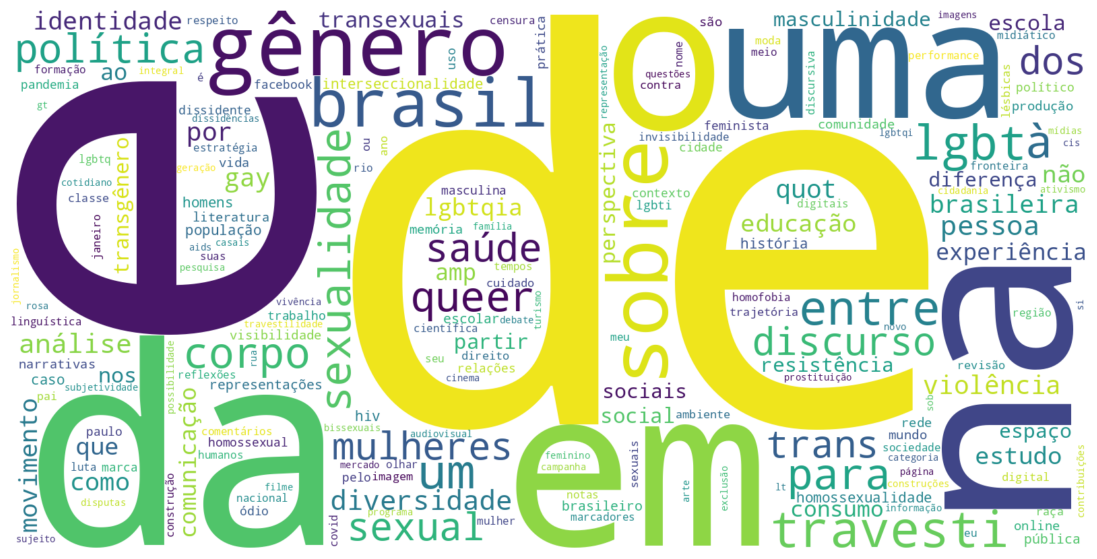

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# junta todos os títulos
texto = " ".join(df["Titulo"].astype(str)).lower()

# correções
texto = texto.replace("travestiss", "travestis")

# gera a nuvem
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    collocations=False
).generate(texto)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

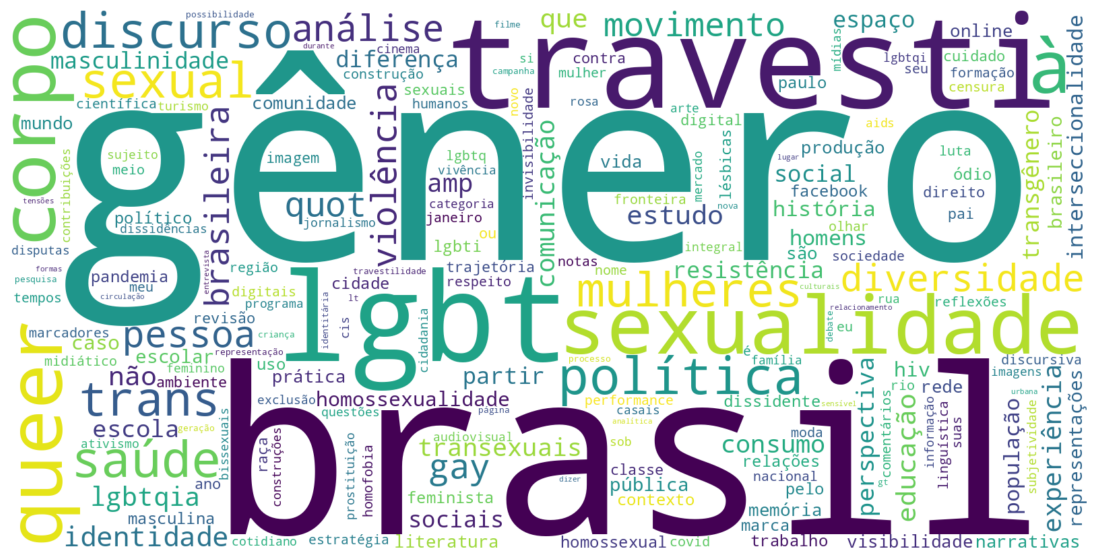

In [22]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

texto = " ".join(df["Titulo"].astype(str)).lower()

# correção
texto = texto.replace("travestiss", "travestis")

stopwords = set(STOPWORDS)

stopwords.update([
    "de","da","do","das","dos",
    "e","em","para","por","com",
    "uma","um","na","no","nas","nos",
    "entre","sobre","como","ao","aos",
    "às","as","os","o","a"
])

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    stopwords=stopwords,
    collocations=False
).generate(texto)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [23]:
from collections import Counter
import pandas as pd
import re

texto = " ".join(df["Titulo"].astype(str)).lower()

# corrigir erro
texto = texto.replace("travestiss", "travestis")

# remover caracteres especiais
texto = re.sub(r'[^\w\s]', ' ', texto)

# lista de stopwords
stopwords = {
    'de','da','do','das','dos',
    'e','em','para','por','com',
    'uma','um','na','no','nas','nos',
    'entre','sobre','como','ao','aos',
    'as','os','o','a'
}

palavras = [
    p for p in texto.split()
    if len(p) > 2 and p not in stopwords
]

frequencia = Counter(palavras)

top_palavras = pd.DataFrame(
    frequencia.most_common(20),
    columns=['Palavra', 'Frequência']
)

top_palavras

,Palavra,Frequência
0,gênero,55
1,brasil,39
2,lgbt,32
3,travestis,30
4,queer,26
5,saúde,23
6,sexual,22
7,mulheres,21
8,trans,21
9,diversidade,21


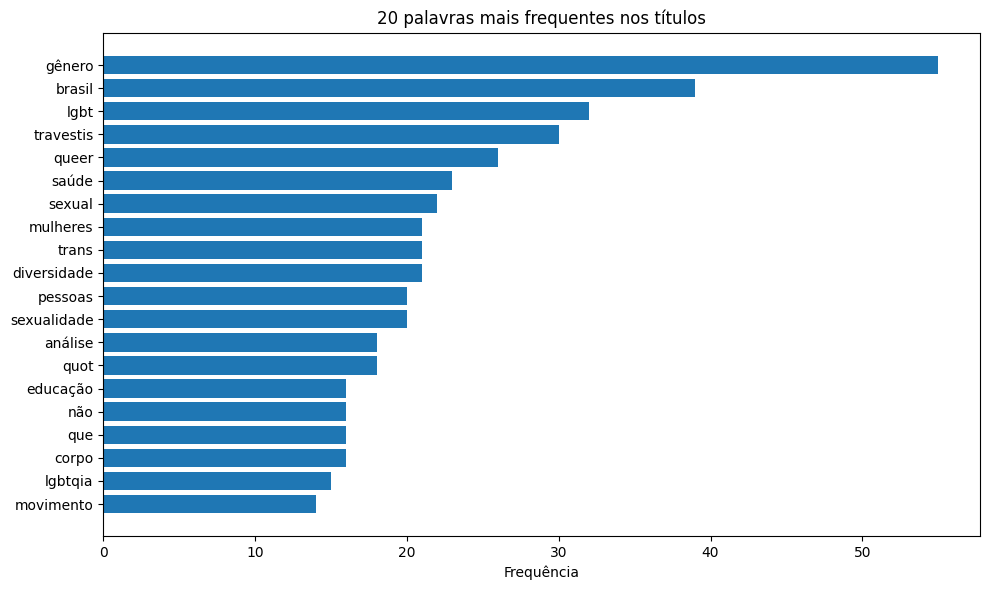

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_palavras['Palavra'][::-1],
    top_palavras['Frequência'][::-1]
)

plt.xlabel('Frequência')
plt.ylabel('')
plt.title('20 palavras mais frequentes nos títulos')
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Palavras mais frequentes nos títulos - Corpus LGBTQIA+')

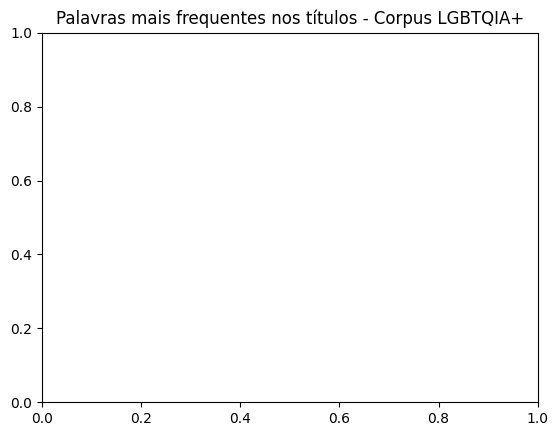

In [25]:
plt.title('Palavras mais frequentes nos títulos - Corpus LGBTQIA+')

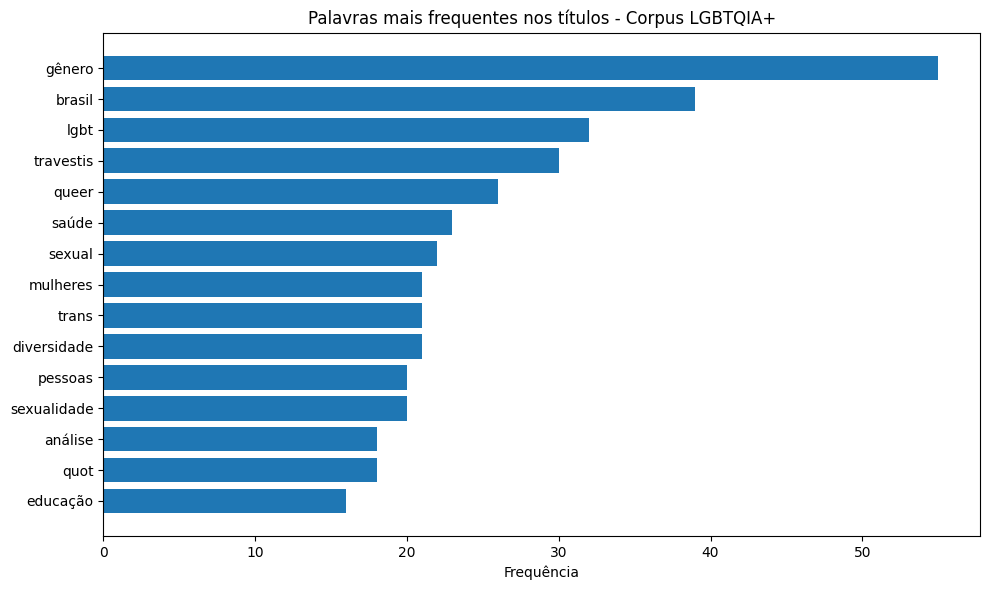

In [26]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import re

# Junta todos os títulos
texto = " ".join(df["Titulo"].astype(str)).lower()

# Corrige a palavra
texto = texto.replace("travestiss", "travestis")

# Remove pontuação
texto = re.sub(r'[^\w\s]', ' ', texto)

# Stopwords
stopwords = {
    'de','da','do','das','dos',
    'e','em','para','por','com',
    'uma','um','na','no','nas','nos',
    'entre','sobre','como','ao','aos',
    'as','os','o','a'
}

# Lista de palavras
palavras = [
    p for p in texto.split()
    if len(p) > 2 and p not in stopwords
]

# Frequência
frequencia = Counter(palavras)

# Top 15
top_palavras = pd.DataFrame(
    frequencia.most_common(15),
    columns=['Palavra', 'Frequência']
)

# Gráfico
plt.figure(figsize=(10,6))

plt.barh(
    top_palavras['Palavra'][::-1],
    top_palavras['Frequência'][::-1]
)

plt.title('Palavras mais frequentes nos títulos - Corpus LGBTQIA+')
plt.xlabel('Frequência')
plt.tight_layout()

plt.show()

In [27]:
top_palavras.head(20)

,Palavra,Frequência
0,gênero,55
1,brasil,39
2,lgbt,32
3,travestis,30
4,queer,26
5,saúde,23
6,sexual,22
7,mulheres,21
8,trans,21
9,diversidade,21


In [ ]:

)